In [ ]:
#!pip install requests

Defaulting to user installation because normal site-packages is not writeable


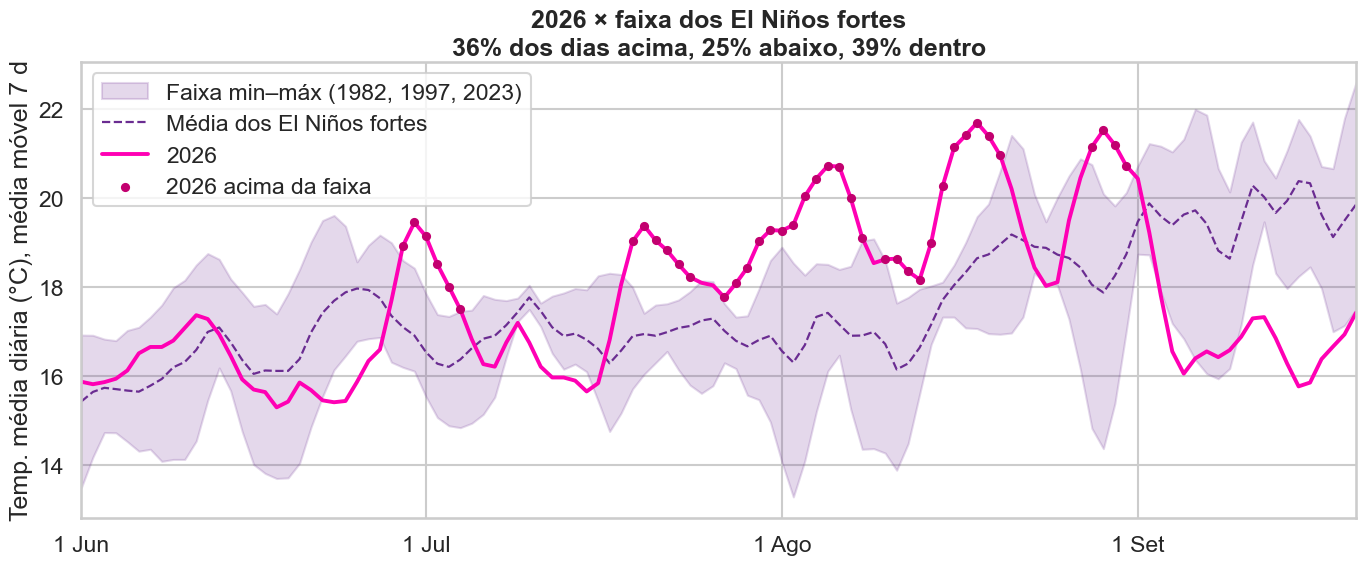

In [11]:
# G1: Faixa dos El Niños fortes x ano-alvo
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sns.set_theme(style="whitegrid", context="talk")

ANO_ALVO, ANOS_REF, ANOS_CONTRASTE = 2026, [1982, 1997, 2023], [2019]   # se tiver 2015: [1982, 1997, 2015, 2023]
ANOS = sorted(ANOS_REF + ANOS_CONTRASTE + [ANO_ALVO])
cores = {1982: "#8C8C8C", 1997: "#2B7BBA", 2015: "#E69F00", 2019: "#7FB77E", 2023: "#6A2C91", 2026: "#FF00B4"}

PASTA = Path("../data/gold") if Path("../data/gold").exists() else Path("data/gold")   # notebook/ -> ../data/gold
dados = {}
for ano in ANOS:
    arq = PASTA / f"ddm_clima_sp_{ano}-01-01_{ano}-09-20.csv"
    if not arq.exists():
        raise FileNotFoundError(f"CSV de {ano} não encontrado em {PASTA.resolve()}")
    d = pd.read_csv(arq, parse_dates=["Data"])
    d = d[d.Data >= f"{ano}-06-01"].copy()                      # recorte 01/06 a 20/09
    d["dia_periodo"] = (d.Data - pd.Timestamp(f"{ano}-06-01")).dt.days
    dados[ano] = d.set_index("dia_periodo")

tm = pd.DataFrame({a: dados[a]["Temperatura_media"] for a in ANOS}).rolling(7, center=True, min_periods=3).mean()
ref = tm[ANOS_REF]
lo, hi, med, alvo = ref.min(axis=1), ref.max(axis=1), ref.mean(axis=1), tm[ANO_ALVO]
acima, abaixo = (alvo > hi).mean(), (alvo < lo).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.fill_between(tm.index, lo, hi, color=cores[2023], alpha=.18, label=f"Faixa min–máx ({', '.join(map(str, ANOS_REF))})")
ax.plot(med, color=cores[2023], ls="--", lw=1.6, label="Média dos El Niños fortes")
ax.plot(alvo, color=cores[ANO_ALVO], lw=2.8, label=str(ANO_ALVO))
ax.scatter(alvo.index[alvo > hi], alvo[alvo > hi], s=26, color="#C2006F", zorder=5, label=f"{ANO_ALVO} acima da faixa")
ax.set_xticks([0, 30, 61, 92]); ax.set_xticklabels(["1 Jun", "1 Jul", "1 Ago", "1 Set"]); ax.set_xlim(0, 111)
ax.set_ylabel("Temp. média diária (°C), média móvel 7 d")
ax.set_title(f"{ANO_ALVO} × faixa dos El Niños fortes\n{acima:.0%} dos dias acima, {abaixo:.0%} abaixo, {1-acima-abaixo:.0%} dentro", fontweight="bold")
ax.legend(loc="upper left")
plt.tight_layout()
plt.savefig("g1_banda_el_nino.png", dpi=150)
plt.show()

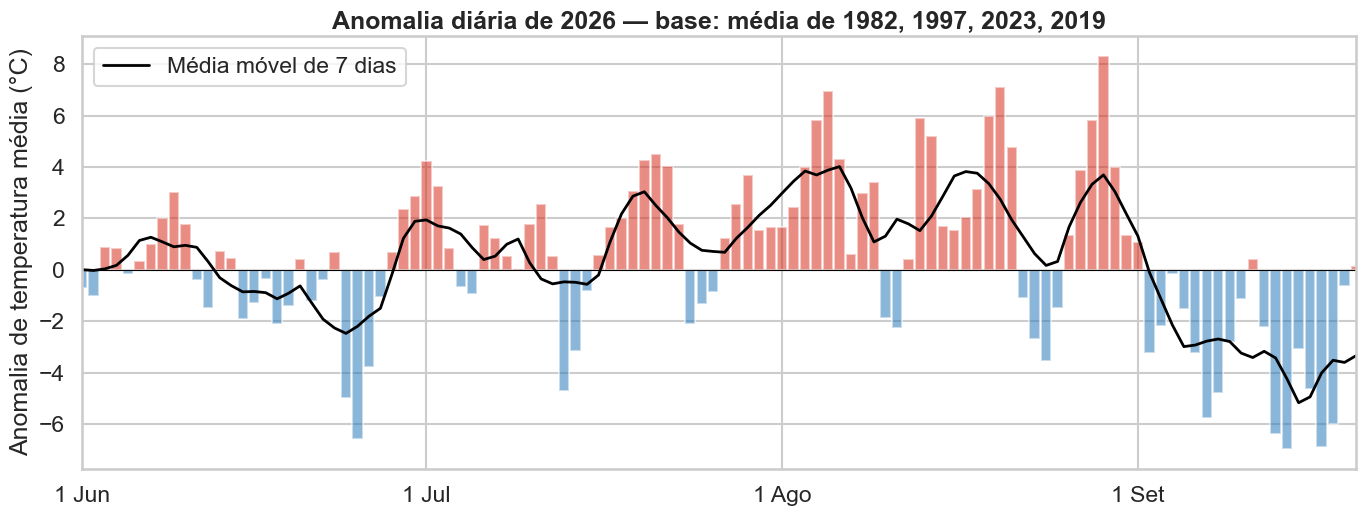

In [12]:
# G2: Anomalia diária de temperatura média
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sns.set_theme(style="whitegrid", context="talk")

ANO_ALVO, ANOS_REF, ANOS_CONTRASTE = 2026, [1982, 1997, 2023], [2019]   # se tiver 2015: [1982, 1997, 2015, 2023]
ANOS = sorted(ANOS_REF + ANOS_CONTRASTE + [ANO_ALVO])
cores = {1982: "#8C8C8C", 1997: "#2B7BBA", 2015: "#E69F00", 2019: "#7FB77E", 2023: "#6A2C91", 2026: "#FF00B4"}

PASTA = Path("../data/gold") if Path("../data/gold").exists() else Path("data/gold")   # notebook/ -> ../data/gold
dados = {}
for ano in ANOS:
    arq = PASTA / f"ddm_clima_sp_{ano}-01-01_{ano}-09-20.csv"
    if not arq.exists():
        raise FileNotFoundError(f"CSV de {ano} não encontrado em {PASTA.resolve()}")
    d = pd.read_csv(arq, parse_dates=["Data"])
    d = d[d.Data >= f"{ano}-06-01"].copy()                      # recorte 01/06 a 20/09
    d["dia_periodo"] = (d.Data - pd.Timestamp(f"{ano}-06-01")).dt.days
    dados[ano] = d.set_index("dia_periodo")

base = pd.DataFrame({a: dados[a]["Temperatura_media"] for a in ANOS_REF + ANOS_CONTRASTE}).mean(axis=1)
nome_base = "média de " + ", ".join(map(str, ANOS_REF + ANOS_CONTRASTE))
# Com climatologia de 30 anos (ver script opcional no fim), troque as 2 linhas acima por:
# base = pd.read_csv(PASTA / "climatologia_1991-2020.csv").set_index("dia_periodo")["Tmed"]; nome_base = "climatologia 1991–2020"

an = dados[ANO_ALVO]["Temperatura_media"] - base.reindex(dados[ANO_ALVO].index)

fig, ax = plt.subplots(figsize=(14, 5.5))
ax.bar(an.index, an, color=np.where(an >= 0, "#D7301F", "#2B7BBA"), alpha=.55, width=.9)
ax.plot(an.rolling(7, center=True, min_periods=3).mean(), color="black", lw=2, label="Média móvel de 7 dias")
ax.axhline(0, color="black", lw=.8)
ax.set_xticks([0, 30, 61, 92]); ax.set_xticklabels(["1 Jun", "1 Jul", "1 Ago", "1 Set"]); ax.set_xlim(0, 111)
ax.set_ylabel("Anomalia de temperatura média (°C)")
ax.set_title(f"Anomalia diária de {ANO_ALVO} — base: {nome_base}", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("g2_anomalia_diaria.png", dpi=150)
plt.show()

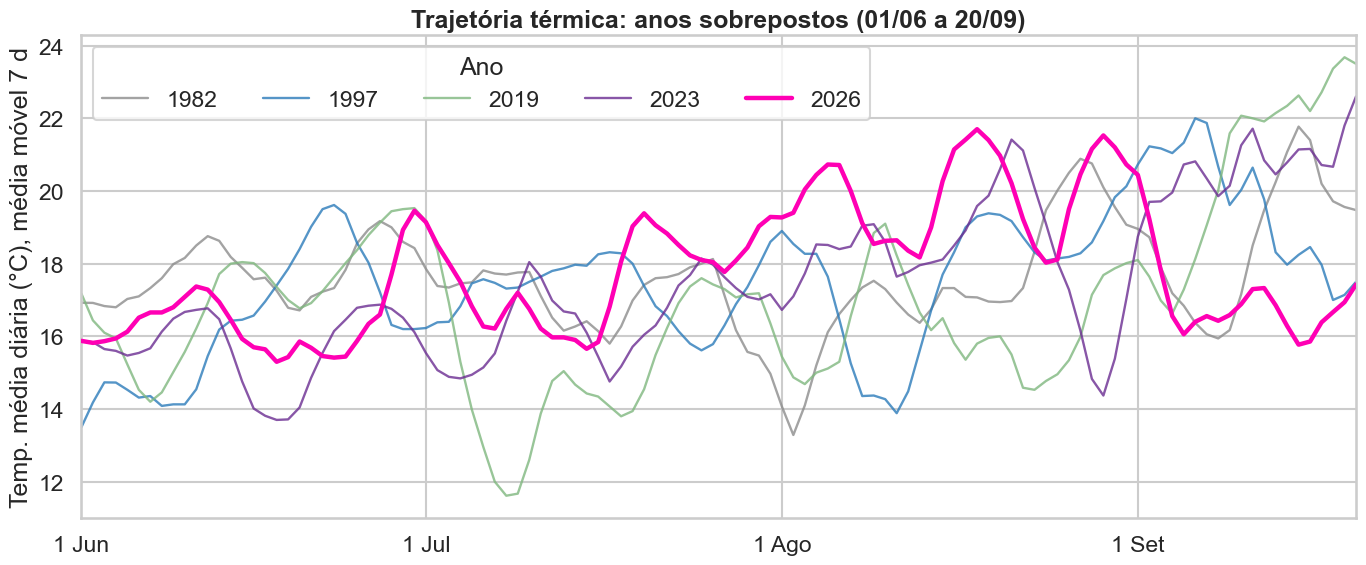

In [13]:
# G3: Médias móveis sobrepostas
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sns.set_theme(style="whitegrid", context="talk")

ANO_ALVO, ANOS_REF, ANOS_CONTRASTE = 2026, [1982, 1997, 2023], [2019]   # se tiver 2015: [1982, 1997, 2015, 2023]
ANOS = sorted(ANOS_REF + ANOS_CONTRASTE + [ANO_ALVO])
cores = {1982: "#8C8C8C", 1997: "#2B7BBA", 2015: "#E69F00", 2019: "#7FB77E", 2023: "#6A2C91", 2026: "#FF00B4"}

PASTA = Path("../data/gold") if Path("../data/gold").exists() else Path("data/gold")   # notebook/ -> ../data/gold
dados = {}
for ano in ANOS:
    arq = PASTA / f"ddm_clima_sp_{ano}-01-01_{ano}-09-20.csv"
    if not arq.exists():
        raise FileNotFoundError(f"CSV de {ano} não encontrado em {PASTA.resolve()}")
    d = pd.read_csv(arq, parse_dates=["Data"])
    d = d[d.Data >= f"{ano}-06-01"].copy()                      # recorte 01/06 a 20/09
    d["dia_periodo"] = (d.Data - pd.Timestamp(f"{ano}-06-01")).dt.days
    dados[ano] = d.set_index("dia_periodo")

tm = pd.DataFrame({a: dados[a]["Temperatura_media"] for a in ANOS}).rolling(7, center=True, min_periods=3).mean()

fig, ax = plt.subplots(figsize=(14, 6))
for a in ANOS:
    destaque = a == ANO_ALVO
    ax.plot(tm[a], color=cores[a], lw=3.2 if destaque else 1.7, alpha=1 if destaque else .8, zorder=5 if destaque else 2, label=str(a))
ax.set_xticks([0, 30, 61, 92]); ax.set_xticklabels(["1 Jun", "1 Jul", "1 Ago", "1 Set"]); ax.set_xlim(0, 111)
ax.set_ylabel("Temp. média diária (°C), média móvel 7 d")
ax.set_title("Trajetória térmica: anos sobrepostos (01/06 a 20/09)", fontweight="bold")
ax.legend(title="Ano", ncol=len(ANOS))
plt.tight_layout()
plt.savefig("g3_medias_moveis.png", dpi=150)
plt.show()

In [14]:
# G4: Niño 3.4 x temperatura local  (precisa de data/gold/nino34.csv com colunas Data,nino34)
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sns.set_theme(style="whitegrid", context="talk")

ANO_ALVO, ANOS_REF, ANOS_CONTRASTE = 2026, [1982, 1997, 2023], [2019]   # se tiver 2015: [1982, 1997, 2015, 2023]
ANOS = sorted(ANOS_REF + ANOS_CONTRASTE + [ANO_ALVO])
cores = {1982: "#8C8C8C", 1997: "#2B7BBA", 2015: "#E69F00", 2019: "#7FB77E", 2023: "#6A2C91", 2026: "#FF00B4"}

PASTA = Path("../data/gold") if Path("../data/gold").exists() else Path("data/gold")   # notebook/ -> ../data/gold
dados = {}
for ano in ANOS:
    arq = PASTA / f"ddm_clima_sp_{ano}-01-01_{ano}-09-20.csv"
    if not arq.exists():
        raise FileNotFoundError(f"CSV de {ano} não encontrado em {PASTA.resolve()}")
    d = pd.read_csv(arq, parse_dates=["Data"])
    d = d[d.Data >= f"{ano}-06-01"].copy()                      # recorte 01/06 a 20/09
    d["dia_periodo"] = (d.Data - pd.Timestamp(f"{ano}-06-01")).dt.days
    dados[ano] = d.set_index("dia_periodo")

nino = pd.read_csv(PASTA / "nino34.csv", parse_dates=["Data"])
meses = {6: "Jun", 7: "Jul", 8: "Ago", 9: "Set"}

tm_mes = pd.DataFrame({a: dados[a].groupby(dados[a].Data.dt.month)["Temperatura_media"].mean() for a in ANOS})
anom = tm_mes.sub(tm_mes.mean(axis=1), axis=0)             # anomalia vs média dos anos carregados

fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
for a in ANOS:
    n = nino[(nino.Data.dt.year == a) & nino.Data.dt.month.isin(meses)]
    lw = 3.2 if a == ANO_ALVO else 1.7
    a1.plot(n.Data.dt.month, n.nino34, marker="o", color=cores[a], lw=lw, label=str(a))
    a2.plot(anom.index, anom[a], marker="o", color=cores[a], lw=lw, label=str(a))
a1.axhline(.5, color="gray", ls=":", lw=1)
a1.set_ylabel("Niño 3.4 (anomalia, °C)")
a2.axhline(0, color="black", lw=.8)
a2.set_ylabel("Anomalia T média mensal na RMSP (°C)")
a2.set_xticks(list(meses)); a2.set_xticklabels(list(meses.values()))
a1.legend(title="Ano", ncol=len(ANOS))
a1.set_title("Pacífico (Niño 3.4) × temperatura local", fontweight="bold")
plt.tight_layout()
plt.savefig("g4_nino34_vs_local.png", dpi=150)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\gold\\nino34.csv'

                                   1982    1997    2019    2023    2026
Temp. média do período (°C)       17.60   17.51   17.01   17.49   17.81
Pico de temp. média diária (°C)   23.80   25.90   25.60   25.40   26.30
Temp. mínima média (°C)           13.98   13.32   12.77   12.94   13.88
Dias com T média ≥ 20 °C          16.00   15.00   16.00   22.00   30.00
Dias com chuva > 10 mm             5.00    6.00    5.00    4.00   14.00
Chuva total (mm)                 196.70  224.00  186.50  103.10  388.10


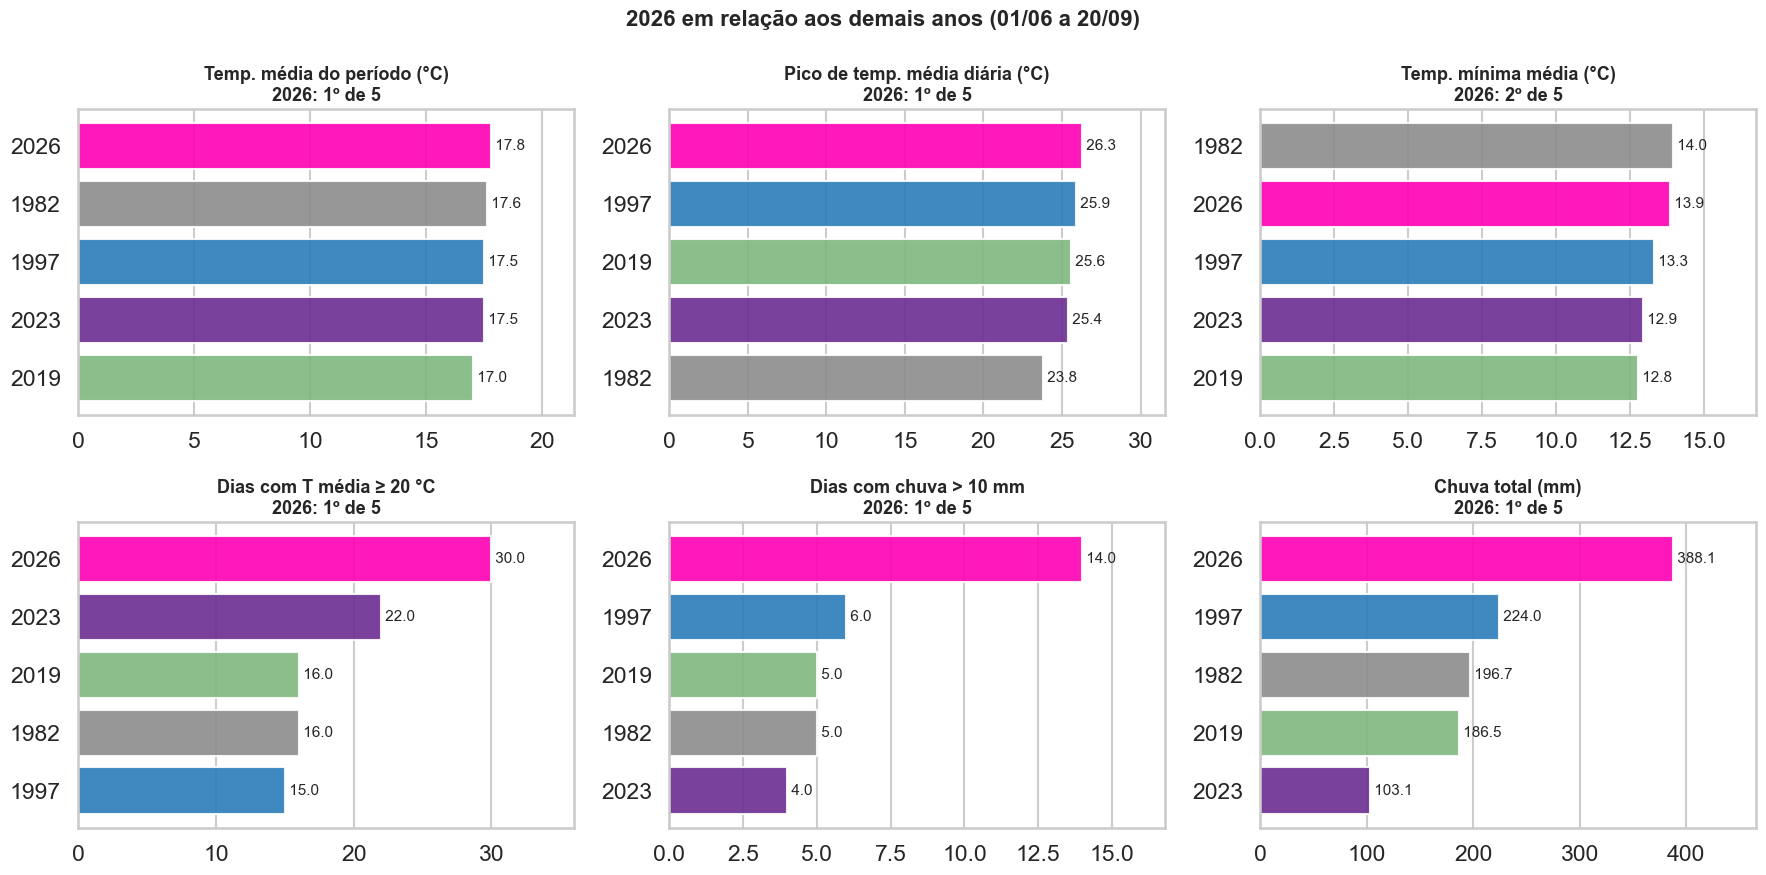

In [15]:
# G5: Ranking de 2026 em seis indicadores
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sns.set_theme(style="whitegrid", context="talk")

ANO_ALVO, ANOS_REF, ANOS_CONTRASTE = 2026, [1982, 1997, 2023], [2019]   # se tiver 2015: [1982, 1997, 2015, 2023]
ANOS = sorted(ANOS_REF + ANOS_CONTRASTE + [ANO_ALVO])
cores = {1982: "#8C8C8C", 1997: "#2B7BBA", 2015: "#E69F00", 2019: "#7FB77E", 2023: "#6A2C91", 2026: "#FF00B4"}

PASTA = Path("../data/gold") if Path("../data/gold").exists() else Path("data/gold")   # notebook/ -> ../data/gold
dados = {}
for ano in ANOS:
    arq = PASTA / f"ddm_clima_sp_{ano}-01-01_{ano}-09-20.csv"
    if not arq.exists():
        raise FileNotFoundError(f"CSV de {ano} não encontrado em {PASTA.resolve()}")
    d = pd.read_csv(arq, parse_dates=["Data"])
    d = d[d.Data >= f"{ano}-06-01"].copy()                      # recorte 01/06 a 20/09
    d["dia_periodo"] = (d.Data - pd.Timestamp(f"{ano}-06-01")).dt.days
    dados[ano] = d.set_index("dia_periodo")

LIMIAR_CALOR, LIMIAR_CHUVA = 20.0, 10.0
tab = pd.DataFrame({a: {
    "Temp. média do período (°C)": dados[a].Temperatura_media.mean(),
    "Pico de temp. média diária (°C)": dados[a].Temperatura_media.max(),
    "Temp. mínima média (°C)": dados[a].Temperatura_minima.mean(),
    f"Dias com T média ≥ {LIMIAR_CALOR:.0f} °C": float((dados[a].Temperatura_media >= LIMIAR_CALOR).sum()),
    f"Dias com chuva > {LIMIAR_CHUVA:.0f} mm": float((dados[a].Chuva_total > LIMIAR_CHUVA).sum()),
    "Chuva total (mm)": dados[a].Chuva_total.sum()} for a in ANOS})
print(tab.round(2).to_string())

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, (nome, linha) in zip(axes.ravel(), tab.iterrows()):
    linha = linha.sort_values()
    ax.barh([str(a) for a in linha.index], linha.values, color=[cores[a] for a in linha.index], alpha=.9)
    for i, v in enumerate(linha.values):
        ax.text(v, i, f" {v:.1f}", va="center", fontsize=11)
    rank = int((linha > linha[ANO_ALVO]).sum()) + 1
    ax.set_title(f"{nome}\n{ANO_ALVO}: {rank}º de {len(linha)}", fontsize=13, fontweight="bold")
    ax.set_xlim(0, linha.max() * 1.2)
    ax.grid(axis="y", visible=False)
fig.suptitle(f"{ANO_ALVO} em relação aos demais anos (01/06 a 20/09)", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("g5_ranking_indicadores.png", dpi=150)
plt.show()

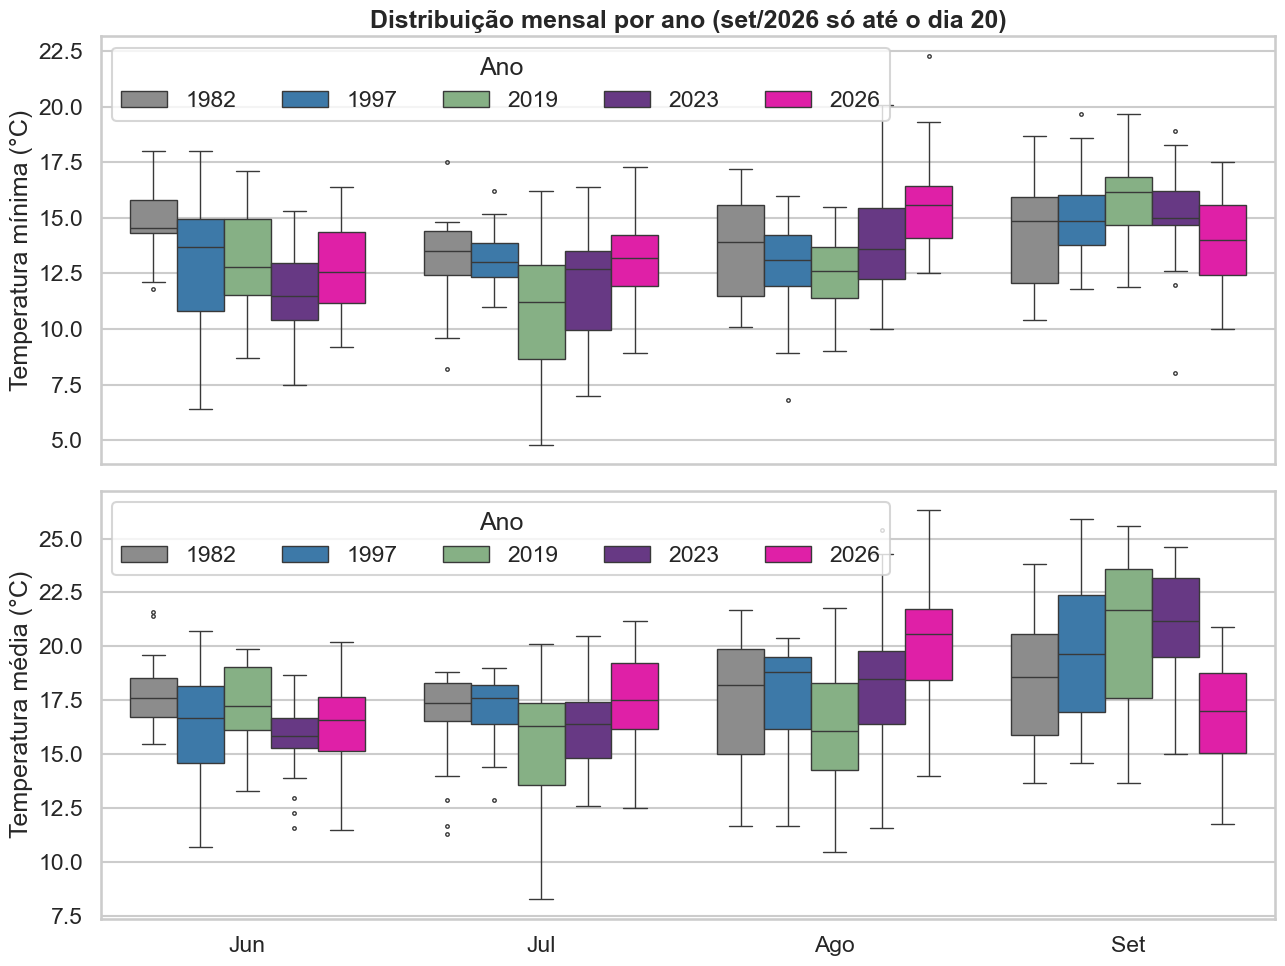

In [17]:
# G7: Boxplots mensais de Tmin e Tmed
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sns.set_theme(style="whitegrid", context="talk")

ANO_ALVO, ANOS_REF, ANOS_CONTRASTE = 2026, [1982, 1997, 2023], [2019]   # se tiver 2015: [1982, 1997, 2015, 2023]
ANOS = sorted(ANOS_REF + ANOS_CONTRASTE + [ANO_ALVO])
cores = {1982: "#8C8C8C", 1997: "#2B7BBA", 2015: "#E69F00", 2019: "#7FB77E", 2023: "#6A2C91", 2026: "#FF00B4"}

PASTA = Path("../data/gold") if Path("../data/gold").exists() else Path("data/gold")   # notebook/ -> ../data/gold
dados = {}
for ano in ANOS:
    arq = PASTA / f"ddm_clima_sp_{ano}-01-01_{ano}-09-20.csv"
    if not arq.exists():
        raise FileNotFoundError(f"CSV de {ano} não encontrado em {PASTA.resolve()}")
    d = pd.read_csv(arq, parse_dates=["Data"])
    d = d[d.Data >= f"{ano}-06-01"].copy()                      # recorte 01/06 a 20/09
    d["dia_periodo"] = (d.Data - pd.Timestamp(f"{ano}-06-01")).dt.days
    dados[ano] = d.set_index("dia_periodo")

meses = {6: "Jun", 7: "Jul", 8: "Ago", 9: "Set"}
longo = pd.concat([dados[a].assign(ano=a) for a in ANOS]).reset_index(drop=True)
longo["Mês"] = longo.Data.dt.month.map(meses)

fig, axes = plt.subplots(2, 1, figsize=(13, 10), sharex=True)
for ax, col, rotulo in zip(axes, ["Temperatura_minima", "Temperatura_media"], ["Temperatura mínima (°C)", "Temperatura média (°C)"]):
    sns.boxplot(data=longo, x="Mês", y=col, hue="ano", order=list(meses.values()), palette=cores, fliersize=2.5, linewidth=1, ax=ax)
    ax.set_ylabel(rotulo); ax.set_xlabel("")
    ax.legend(title="Ano", ncol=len(ANOS), loc="upper left")
axes[0].set_title("Distribuição mensal por ano (set/2026 só até o dia 20)", fontweight="bold")
plt.tight_layout()
plt.savefig("g7_boxplots_mensais.png", dpi=150)
plt.show()

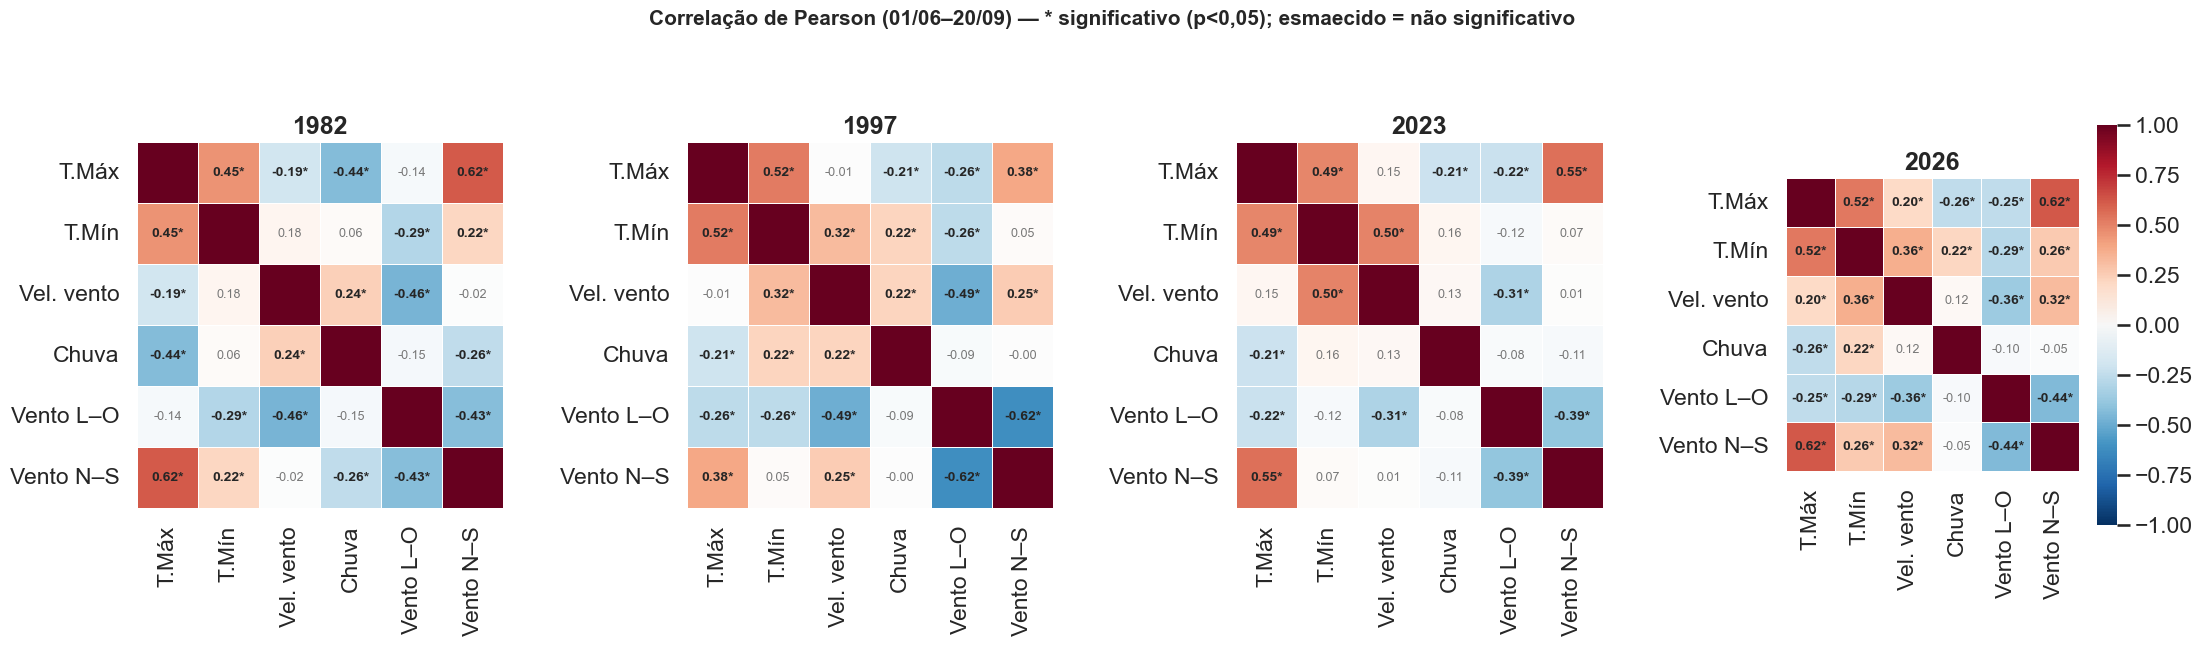

In [18]:
# G8: Matriz de correlação com significância (p < 0,05 marcado com *)
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path
sns.set_theme(style="whitegrid", context="talk")

ANO_ALVO, ANOS_REF, ANOS_CONTRASTE = 2026, [1982, 1997, 2023], [2019]   # se tiver 2015: [1982, 1997, 2015, 2023]
ANOS = sorted(ANOS_REF + ANOS_CONTRASTE + [ANO_ALVO])
cores = {1982: "#8C8C8C", 1997: "#2B7BBA", 2015: "#E69F00", 2019: "#7FB77E", 2023: "#6A2C91", 2026: "#FF00B4"}

PASTA = Path("../data/gold") if Path("../data/gold").exists() else Path("data/gold")   # notebook/ -> ../data/gold
dados = {}
for ano in ANOS:
    arq = PASTA / f"ddm_clima_sp_{ano}-01-01_{ano}-09-20.csv"
    if not arq.exists():
        raise FileNotFoundError(f"CSV de {ano} não encontrado em {PASTA.resolve()}")
    d = pd.read_csv(arq, parse_dates=["Data"])
    d = d[d.Data >= f"{ano}-06-01"].copy()                      # recorte 01/06 a 20/09
    d["dia_periodo"] = (d.Data - pd.Timestamp(f"{ano}-06-01")).dt.days
    dados[ano] = d.set_index("dia_periodo")

from scipy import stats
from matplotlib.patches import Rectangle

direcoes = {"Norte": 0, "Nordeste": 45, "Leste": 90, "Sudeste": 135, "Sul": 180, "Sudoeste": 225, "Oeste": 270, "Noroeste": 315}
nomes = ["T.Máx", "T.Mín", "Vel. vento", "Chuva", "Vento L–O", "Vento N–S"]
anos_plot = ANOS_REF + [ANO_ALVO]

fig, axes = plt.subplots(1, len(anos_plot), figsize=(6.5 * len(anos_plot), 6.5))
for k, (ax, a) in enumerate(zip(axes, anos_plot)):
    d = dados[a]
    th = np.deg2rad(d.Direcao_vento.map(direcoes))
    x = pd.DataFrame({"T.Máx": d.Temperatura_maxima, "T.Mín": d.Temperatura_minima, "Vel. vento": d.Velocidade_vento_max,
                      "Chuva": d.Chuva_total, "Vento L–O": np.sin(th), "Vento N–S": np.cos(th)})
    r = x.corr()
    p = pd.DataFrame(np.nan, index=nomes, columns=nomes)
    for i in nomes:
        for j in nomes:
            if i != j:
                p.loc[i, j] = stats.pearsonr(x[i], x[j])[1]
    sns.heatmap(r, vmin=-1, vmax=1, cmap="RdBu_r", cbar=(k == len(anos_plot) - 1), square=True,
                linewidths=.5, linecolor="white", ax=ax, cbar_kws={"shrink": 0.8})
    for i, ni in enumerate(nomes):
        for j, nj in enumerate(nomes):
            if i == j:
                continue
            if p.loc[ni, nj] < 0.05:
                ax.text(j + .5, i + .5, f"{r.loc[ni, nj]:.2f}*", ha="center", va="center", fontweight="bold", fontsize=10)
            else:
                ax.add_patch(Rectangle((j, i), 1, 1, facecolor="white", alpha=.72, lw=0))
                ax.text(j + .5, i + .5, f"{r.loc[ni, nj]:.2f}", ha="center", va="center", color="#777", fontsize=9)
    ax.set_title(str(a), fontweight="bold")
fig.suptitle("Correlação de Pearson (01/06–20/09) — * significativo (p<0,05); esmaecido = não significativo", fontsize=15, fontweight="bold")
fig.subplots_adjust(wspace=0.5)
plt.savefig("g8_correlacoes_significancia.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# OPCIONAL: baixar climatologia 1991–2020 (Open-Meteo) -> data/gold/climatologia_1991-2020.csv
import requests, pandas as pd
from pathlib import Path
PASTA = Path("../data/gold") if Path("../data/gold").exists() else Path("data/gold")
LAT, LON = -23.55, -46.63            # use as mesmas coordenadas dos seus CSV
r = requests.get("https://archive-api.open-meteo.com/v1/archive", timeout=180, params=dict(
    latitude=LAT, longitude=LON, start_date="1991-01-01", end_date="2020-12-31",
    daily="temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum", timezone="America/Sao_Paulo"))
r.raise_for_status()
d = pd.DataFrame(r.json()["daily"]); d["time"] = pd.to_datetime(d["time"])
d = d.rename(columns={"temperature_2m_mean": "Tmed", "temperature_2m_max": "Tmax", "temperature_2m_min": "Tmin", "precipitation_sum": "Chuva"})
md = d.time.dt.strftime("%m-%d")
d = d[(md >= "06-01") & (md <= "09-20")].copy()
d["dia_periodo"] = (d.time - pd.to_datetime(d.time.dt.year.astype(str) + "-06-01")).dt.days
d.groupby("dia_periodo")[["Tmed", "Tmax", "Tmin", "Chuva"]].mean().reset_index().to_csv(PASTA / "climatologia_1991-2020.csv", index=False)

In [21]:
# OPCIONAL: baixar Niño 3.4 (NOAA PSL) -> data/gold/nino34.csv
import requests, pandas as pd
from pathlib import Path
PASTA = Path("../data/gold") if Path("../data/gold").exists() else Path("data/gold")
txt = requests.get("https://psl.noaa.gov/data/correlation/nina34.anom.data", timeout=60).text
linhas = []
for ln in txt.splitlines():
    p = ln.split()
    if len(p) == 13 and p[0].isdigit():
        for m, v in enumerate(p[1:], 1):
            if float(v) > -90:
                linhas.append((pd.Timestamp(int(p[0]), m, 1), float(v)))
pd.DataFrame(linhas, columns=["Data", "nino34"]).to_csv(PASTA / "nino34.csv", index=False)